In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic',
 'anagrams',
 'anagrams',
 'anscombe',
 'anscombe',
 'attention',
 'attention',
 'brain_networks',
 'brain_networks',
 'car_crashes',
 'car_crashes',
 'diamonds',
 'diamonds',
 'dots',
 'dots',
 'dowjones',
 'dowjones',
 'exercise',
 'exercise',
 'flights',
 'flights',
 'fmri',
 'fmri',
 'geyser',
 'geyser',
 'glue',
 'glue',
 'healthexp',
 'healthexp',
 'iris',
 'iris',
 'mpg',
 'mpg',
 'penguins',
 'penguins',
 'planets',
 'planets',
 'seaice',
 'seaice',
 'taxis',
 'taxis',
 'tips',
 'tips',
 'titanic',
 'titanic',
 'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'plan

In [3]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
df['date'] = pd.to_datetime("01-"+df['month'].astype(str)+'-'+df['year'].astype(str))
df.set_index('date',inplace=True)
df.head()

,year,month,passengers
date,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


<Axes: xlabel='date', ylabel='passengers'>

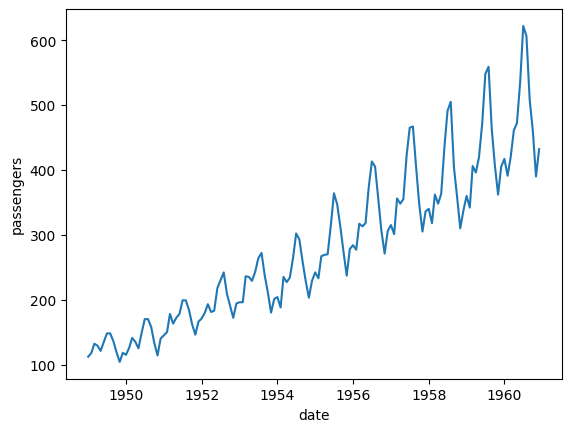

In [5]:
sns.lineplot(data=df,x=df.index,y=df.passengers)

ARIMA models combine two models and 1 method. Two models are  Auto Regression(AR) and Moving Average(MA). One method is differencing(I). These three works together when the time series we use is non-stationary. In simple words, we can call a model ARIMA model if we apply differencing (I) at least once to make the data stationary and combine autoregressive and moving averages to make some forecasting based on old time-series data.

Test for stationarity using the augmented dickey fuller test.
If the time series is stationary try to fit the ARMA model, and if the time series is non-stationary then seek the value of d. 

## Checking stationarity

In [6]:
from statsmodels.tsa.stattools import adfuller

data = df['passengers']

# Perform Augmented Dickey-Fuller test
result = adfuller(data)

# Extract test statistic and p-value
test_statistic = result[0]
p_value = result[1]

# Check if the data is stationary based on p-value
if p_value < 0.05:
    print("Data is stationary")
else:
    print("Data is not stationary")

Data is not stationary


## Differencing -- non stationary data --> stationary data

In [7]:
df['diff_passengers'] = df['passengers'].diff()

## Re-confirming Data stationarity

In [8]:
temperature_data = df['diff_passengers'].dropna()

# Perform Augmented Dickey-Fuller test
result = adfuller(temperature_data)

# Extract test statistic and p-value
test_statistic = result[0]
p_value = result[1]

# Check if the data is stationary based on p-value
if p_value < 0.05:
    print("Data is stationary")
else:
    print("Data is not stationary")

Data is not stationary


## 2nd order differencing

In [9]:
df['diff1_passengers'] = df['diff_passengers'].diff()

In [10]:
data = df['diff1_passengers'].dropna()

# Perform Augmented Dickey-Fuller test
result = adfuller(data)

# Extract test statistic and p-value
test_statistic = result[0]
p_value = result[1]

# Check if the data is stationary based on p-value
if p_value < 0.05:
    print("Data is stationary")
else:
    print("Data is not stationary")

Data is stationary


## ACF & PACF

Shaded part is insignificant area

Area outiside of shaded is called significant area

The point where the lines are exceeding the insignificant area, that is we are gonna consider

p: Look at PACF to determine the number of AR terms (lags).

d: Look at stationarity and use differencing to determine the degree of differencing.

q: Look at ACF to determine the number of MA terms (lags).

The lag at which the spikes die off or become insignificant gives you a good estimate for the q value.


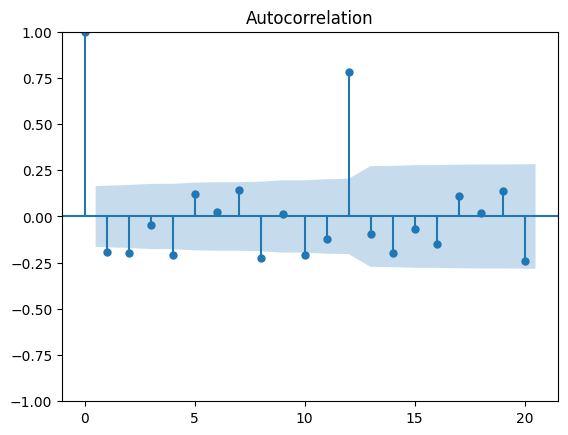

In [11]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_acf(data,lags=20)
plt.show()

## q is 2 
## d (differencing) is already 2

The partial autocorrelation function (PACF) shows significant spikes at lag 1 and 2, which are above the shaded confidence interval.

After lag 2, the PACF values drop within the confidence interval.

The p value (the order of the AR component in ARIMA) is 2, as the significant lags are at 1 and 2.

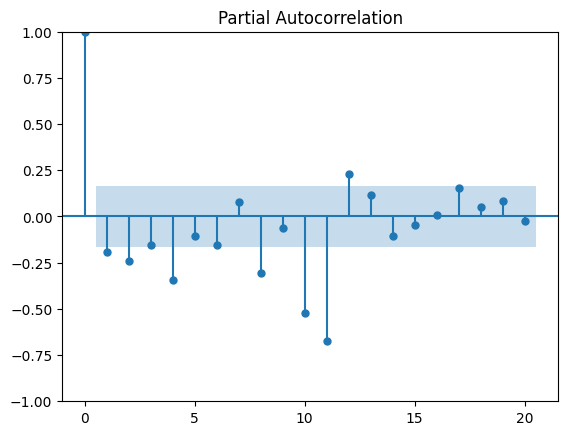

In [12]:
plot_pacf(data,lags=20)
plt.show()

## Train test split

In [13]:
split_index = int(len(df) * 0.8)

# Split the DataFrame into training and testing sets
train = df.iloc[:split_index]
test = df.iloc[split_index:]

## Build ARIMA model

In [14]:
p, d, q = 2, 2, 2

# Train the ARIMA model
model = ARIMA(train['passengers'], order=(p, d, q))
model = model.fit()

# Summary of the model
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  115
Model:                 ARIMA(2, 2, 2)   Log Likelihood                -523.084
Date:                Thu, 05 Dec 2024   AIC                           1056.169
Time:                        19:48:46   BIC                           1069.806
Sample:                    01-01-1949   HQIC                          1061.702
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5035      0.122     -4.142      0.000      -0.742      -0.265
ar.L2          0.0912      0.099      0.921      0.357      -0.103       0.285
ma.L1         -0.0552     11.924     -0.005      0.9

In [15]:
prediction = model.predict(test.index[0],test.index[-1])
df["ARIMA"] = prediction
df

,year,month,passengers,diff_passengers,diff1_passengers,ARIMA
date,,,,,,
1949-01-01,1949,Jan,112,NaN,NaN,NaN
1949-02-01,1949,Feb,118,6.0,NaN,NaN
1949-03-01,1949,Mar,132,14.0,8.0,NaN
1949-04-01,1949,Apr,129,-3.0,-17.0,NaN
1949-05-01,1949,May,121,-8.0,-5.0,NaN
...,...,...,...,...,...,...
1960-08-01,1960,Aug,606,-16.0,-103.0,591.183555
1960-09-01,1960,Sep,508,-98.0,-82.0,594.661104
1960-10-01,1960,Oct,461,-47.0,51.0,598.138804


<Axes: xlabel='date', ylabel='passengers'>

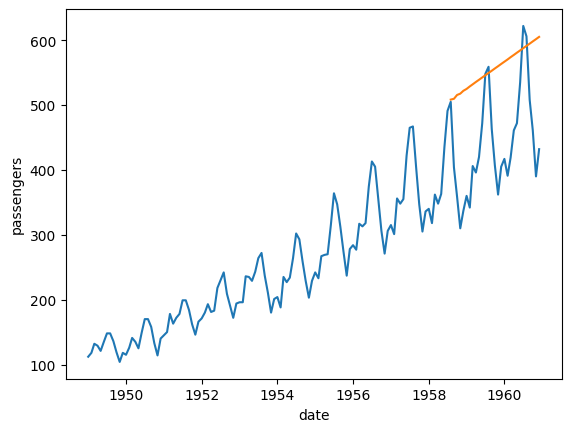

In [16]:
sns.lineplot(data=df,x=df.index,y='passengers')
sns.lineplot(data=df,x=df.index,y='ARIMA')

## Evaluation

In [17]:
mae = mean_absolute_error(test['passengers'], prediction)
mse = mean_squared_error(test['passengers'], prediction)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 120.269
MSE: 18381.426
RMSE: 135.578


## SARIMAX
Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors. 

It is used for time series data that has seasonality and can include exogenous variables.

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['passengers'],order=(2,2,2),seasonal_order=(2,2,2,12))
model = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.37417D+00    |proj g|=  7.75769D-01


 This problem is unconstrained.



At iterate    5    f=  3.06572D+00    |proj g|=  2.62975D-02

At iterate   10    f=  2.93599D+00    |proj g|=  2.69863D-02

At iterate   15    f=  2.92940D+00    |proj g|=  7.09873D-03

At iterate   20    f=  2.92623D+00    |proj g|=  5.97424D-03

At iterate   25    f=  2.92106D+00    |proj g|=  5.84975D-03

At iterate   30    f=  2.92067D+00    |proj g|=  1.60044D-03

At iterate   35    f=  2.92061D+00    |proj g|=  1.32786D-03

At iterate   40    f=  2.92045D+00    |proj g|=  1.17060D-03

At iterate   45    f=  2.92036D+00    |proj g|=  8.03651D-04

At iterate   50    f=  2.92035D+00    |proj g|=  3.52342D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [19]:
prediction = model.predict(test.index[0],test.index[-1])
df["SARIMAX"] = prediction
df

,year,month,passengers,diff_passengers,diff1_passengers,ARIMA,SARIMAX
date,,,,,,,
1949-01-01,1949,Jan,112,NaN,NaN,NaN,NaN
1949-02-01,1949,Feb,118,6.0,NaN,NaN,NaN
1949-03-01,1949,Mar,132,14.0,8.0,NaN,NaN
1949-04-01,1949,Apr,129,-3.0,-17.0,NaN,NaN
1949-05-01,1949,May,121,-8.0,-5.0,NaN,NaN
...,...,...,...,...,...,...,...
1960-08-01,1960,Aug,606,-16.0,-103.0,591.183555,515.772216
1960-09-01,1960,Sep,508,-98.0,-82.0,594.661104,435.655350
1960-10-01,1960,Oct,461,-47.0,51.0,598.138804,363.603148


<Axes: xlabel='date', ylabel='passengers'>

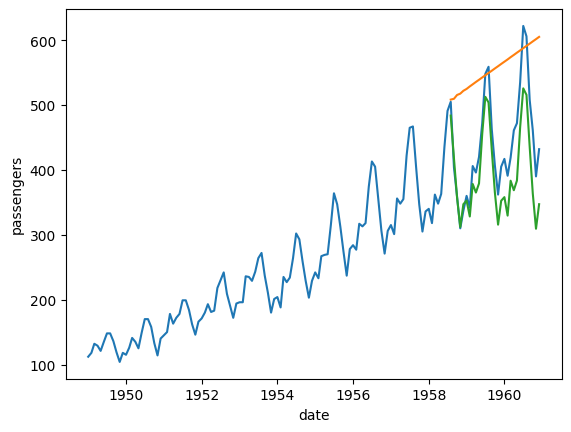

In [20]:
df.dropna()
sns.lineplot(data=df,x=df.index,y='passengers')
sns.lineplot(data=df,x=df.index,y='ARIMA')
sns.lineplot(data=df,x=df.index,y='SARIMAX')

 ## Evaluatio on training data

In [21]:
prediction1 = model.predict(train.index[0],train.index[-1])

mae = mean_absolute_error(train['passengers'], prediction1)
mse = mean_squared_error(train['passengers'], prediction1)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 11.371
MSE: 389.600
RMSE: 19.738


## Evaluatio on testing data

In [22]:
mae = mean_absolute_error(test['passengers'], prediction)
mse = mean_squared_error(test['passengers'], prediction)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 47.439
MSE: 3173.890
RMSE: 56.337


## Forecasting

In [23]:
future_dates = pd.DataFrame(pd.date_range(start='1961-1-01',end='1962-12-01',freq="MS"),columns=["Dates"]) # month start frequency
future_dates.set_index('Dates',inplace=True)
future_dates.head()

""
Dates
1961-01-01
1961-02-01
1961-03-01
1961-04-01
1961-05-01


In [24]:
model.predict(future_dates.index[0],future_dates.index[-1])

1961-01-01    352.122687
1961-02-01    319.143073
1961-03-01    375.324795
1961-04-01    358.606634
1961-05-01    374.693270
1961-06-01    462.505443
1961-07-01    525.874198
1961-08-01    513.916395
1961-09-01    426.395182
1961-10-01    348.307534
1961-11-01    289.358525
1961-12-01    328.203156
1962-01-01    332.502610
1962-02-01    294.943587
1962-03-01    353.520818
1962-04-01    334.748736
1962-05-01    351.741861
1962-06-01    444.815231
1962-07-01    511.343180
1962-08-01    497.202500
1962-09-01    402.123939
1962-10-01    317.852915
1962-11-01    254.083272
1962-12-01    293.793666
Freq: MS, Name: predicted_mean, dtype: float64

<Axes: xlabel='date', ylabel='passengers'>

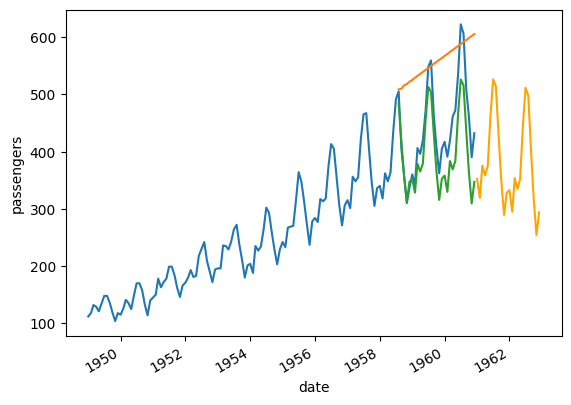

In [25]:
sns.lineplot(data=df,x=df.index,y='passengers')
sns.lineplot(data=df,x=df.index,y='ARIMA')
sns.lineplot(data=df,x=df.index,y='SARIMAX')
model.predict(future_dates.index[0],future_dates.index[-1]).plot(color='orange')
